## 1 - Importando pacotes e bibliotecas

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pandas.tseries.offsets import Week

from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.stattools import adfuller

from pathlib import Path

REPOSITORY_PATH = Path('study.ipynb').resolve().parents[2]

### 1.1 - Funções de Suporte

In [4]:
def pct_active(series):
    # Calcula o percentual de semanas ativas
    return (series > 0).mean()

def coeff_variation(series):
    # Calcula o coeficiente de variação considerando apenas as semanas ativas
    series = series[series > 0]
    if len(series) == 0:
        return np.nan
    return series.std() / series.mean()

def count_bursts(series):
    # Calcula a quantidade de "bursts" ou períodos apartados de atividade
    active = series > 0
    return ((active != active.shift(1)) & active).sum()

## 2 - Carregando dataframes de estudo

| Coluna | Tipo | Descrição |
| :--- | :--- | :--- |
| **date** | string | Data de início da semana (YYYY-MM-DD) |
| **units_sold** | int | Unidades vendidas na semana |
| **revenue_brl** | float | Receita bruta em R$ |
| **avg_price_brl** | float | Preço médio ponderado por unidade vendida (R$) |
| **tv_spend_brl** | float | Investimento em TV aberta e streaming (R$) |
| **google_search_spend_brl** | float | Investimento em Google Search Ads (R$) |
| **google_display_spend_brl** | float | Investimento em Google Display Network (R$) |
| **meta_spend_brl** | float | Investimento em Meta Ads - Facebook + Instagram (R$) |
| **ooh_spend_brl** | float | Investimento em Out-of-Home - painéis, busdoor, mídia exterior (R$) |
| **email_crm_sends** | int | Volume de e-mails enviados via CRM na semana |
| **influencer_spend_brl** | float | Investimento em campanhas com influenciadores (R$) |
| **leads_generated** | int | Leads capturados via formulários e landing pages |
| **website_sessions** | int | Total de sessões no site na semana |
| **coupons_redeemed** | int | Cupons de desconto resgatados na semana |
| **affiliate_commission_brl** | float | Comissão total paga ao programa de afiliados (R$) |
| **competitor_promo_index** | float | Índice de intensidade promocional dos concorrentes (0 a 1) |
| **economic_confidence_index** | float | Índice de confiança do consumidor (normalizado) |
| **is_black_friday** | int | Semana de Black Friday - 1 ou 0 |
| **holiday_week** | int | Semana com feriado nacional de alto impacto no varejo - 1 ou 0 |

In [5]:
df = pd.read_csv(f'{REPOSITORY_PATH}/varejo360/data/raw/varejo360_weekly.csv')

## 3 - Escolha da variável target

A escolha da variávei target se define entre duas possíveis colunas disponíveis no dataframe: `revenue_brl` vs `units_sold`<br> 

Apesar de `revenue_brl` ser mais direta no cálculo do ROI(Return Over Investiment), escolher essa variável como target introduz um viés estrutural no modelo, uma vez que o preço está contido (Receita = Preço x Quantidade).

Dessa forma, será utilizado a variável `units_sold` como variável target. Isso permitirá isolar a influência do preço na mudança do consumidor.



In [6]:
TARGET_COLUMN = 'units_sold'

## 4 - Mapeamento de variáveis

### 4.1 - Inputs de mídia válidos
Como input de mídia válidos, selecionaremos as variáveis que representam investimentos e esforços controlados pela empresa, sendo eles:
- `tv_spend_brl`
- `google_search_spend_brl`
- `google_display_spend_brl`
- `meta_spend_brl`
- `ooh_spend_brl`
- `email_crm_sends`
- `influencer_spend_brl`

O valor gasto nestes canais é decidido pelo time de marketing antes da venda ocorrer, o que reduz o risco de endogeneidade (onde a venda causaria o investimento)

In [7]:
media_channels = ['tv_spend_brl',
                  'google_search_spend_brl',
                  'google_display_spend_brl',
                  'meta_spend_brl',
                  'ooh_spend_brl',
                  'email_crm_sends',
                  'influencer_spend_brl']

### 4.2 - Variáveis de controle/contexto

Como variáveis controle, serão utilizadas as variáveis que definem a demanda baseline, ou seja, sem o investimento da empresa em canais de Marketing.
- `avg_price_brl`
- `competitor_promo_index`
- `economic_confidence_index`
- `is_black_friday`
- `holiday_week`

Diferente dos inputs de mídia, estas variáveis são consideradas exógenas (não está sobre o controle do esforço de mídia da empresa) ou são condicionantes de mercado

In [8]:
control_features = ['avg_price_brl',
                    'competitor_promo_index',
                    'economic_confidence_index',
                    'is_black_friday',
                    'holiday_week']

### 4.3 - Variáveis que não devem entrar no modelo
As variáveis que não devem entrar no modelo são as que representam consequências das vendas (endogeneidade) ou resultados intermediários.

- `affiliate_commission_brl` - Variável Endógena <br>
No modelo de negócio de varejo e e-commerce, comissões de afiliados são tipicamente calculadas como um percentual sobre a venda faturada.
Portanto, a relação causal é Venda → Comissão. Se a comissão for inclusa como causa da venda, o modelo apresentará um ajuste excelente, mas o coeficiente será enviesado e inútil para decisão, pois é possível "comprar" comissão para gerar venda.

- `coupons_redeemed` - Variável Endógena <br>
O resgate de um cupom é parte intrínseca do ato da transação. O volume de cupons é uma métrica de resultado da conversão. Ele não "causa" a intenção de compra de forma primária como a mídia faz, apenas sinaliza que uma transação ocorreu com desconto.

- `website_sessions` - Variável Intermediária <br>
As sessões são causadas pelos investimentos em TV, Search, Meta, etc. Caso as sessões sejam inclusas ao lado dos gastos de mídia, ocorre um fenômeno onde a variável de sessões "rouba" o crédito (coeficiente) da mídia. Isso ocorre pois a mídia causa a sessão, que por sua vez causa a venda. Ao incluir sessões, o impacto real do investimento original é mascarado.

- `leads_generated` - Variável Intermediária <br>
De forma análoga às sessões, leads são resultados intermediários capturados via formulários. Eles são causados pelas campanhas de marketing. Tratá-los como uma "causa" independente das vendas ignora que o esforço de mídia foi o que gerou o lead inicialmente.

In [9]:
drop_features = ['affiliate_commission_brl',
                 'coupons_redeemed',
                 'website_sessions',
                 'leads_generated']

## 5 - Análise Exploratória de Dados (EDA)

In [10]:
sns.set_style("whitegrid")

### 5.1 - Análise de estatística descritiva

In [11]:
# Shape do dataframe disponível
df.shape

(157, 19)

In [12]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 157 entries, 0 to 156
Data columns (total 19 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   date                       157 non-null    str    
 1   units_sold                 157 non-null    int64  
 2   revenue_brl                157 non-null    float64
 3   avg_price_brl              157 non-null    float64
 4   tv_spend_brl               157 non-null    float64
 5   google_search_spend_brl    157 non-null    float64
 6   google_display_spend_brl   157 non-null    float64
 7   meta_spend_brl             157 non-null    float64
 8   ooh_spend_brl              157 non-null    float64
 9   email_crm_sends            157 non-null    int64  
 10  influencer_spend_brl       157 non-null    float64
 11  leads_generated            157 non-null    int64  
 12  website_sessions           157 non-null    int64  
 13  coupons_redeemed           157 non-null    int64  
 14  affil

In [13]:
df.describe()

,units_sold,revenue_brl,avg_price_brl,tv_spend_brl,google_search_spend_brl,google_display_spend_brl,meta_spend_brl,ooh_spend_brl,email_crm_sends,influencer_spend_brl,leads_generated,website_sessions,coupons_redeemed,affiliate_commission_brl,competitor_promo_index,economic_confidence_index,is_black_friday,holiday_week
count,157.000000,1.570000e+02,157.000000,1.570000e+02,157.000000,157.000000,157.000000,157.000000,157.000000,157.000000,157.000000,157.00000,157.000000,157.000000,157.000000,157.000000,157.000000,157.000000
mean,20436.452229,6.328922e+06,310.427452,1.296126e+05,146985.375478,49590.792675,231282.099172,144702.414204,186898.617834,46965.155924,2808.808917,19655.55414,345.133758,61278.559873,0.301436,0.730010,0.038217,0.152866
std,2487.035619,7.428599e+05,18.892064,2.200643e+05,46272.939690,13209.595581,75587.487356,176431.883306,69121.880259,69470.436023,580.539108,2169.82201,251.352498,21491.966830,0.238410,0.145078,0.192332,0.361010
min,14036.000000,4.148378e+06,238.450000,0.000000e+00,74129.460000,21640.490000,91533.290000,0.000000,95820.000000,0.000000,1788.000000,16454.00000,154.000000,22961.690000,0.008600,0.432700,0.000000,0.000000
25%,18701.000000,5.811689e+06,301.780000,0.000000e+00,115203.250000,41352.900000,178568.160000,0.000000,144442.000000,0.000000,2397.000000,18098.00000,252.000000,46146.700000,0.103600,0.606700,0.000000,0.000000
50%,19961.000000,6.141853e+06,311.120000,0.000000e+00,141246.560000,47453.920000,223718.360000,0.000000,166750.000000,0.000000,2672.000000,19178.00000,290.000000,60449.710000,0.238700,0.727200,0.000000,0.000000
75%,21726.000000,6.675530e+06,321.150000,1.820332e+05,172608.670000,55600.830000,266041.490000,320798.110000,199409.000000,101250.900000,3085.000000,20658.00000,349.000000,74085.540000,0.445200,0.852000,0.000000,0.000000
max,28233.000000,8.704138e+06,364.460000,1.028474e+06,396689.830000,102578.040000,657586.110000,563058.400000,450054.000000,251221.650000,6249.000000,30237.00000,1633.000000,126848.140000,0.947300,0.950000,1.000000,1.000000


In [14]:
# Converter data
df["date"] = pd.to_datetime(df["date"])

# Ordenar e definir índice temporal
df = df.sort_values("date").set_index("date")

# Target
y = df[TARGET_COLUMN]

datas_black_friday = df[df['is_black_friday'] == 1].index.values
datas_holiday_week = df[df['holiday_week'] == 1].index.values


### 5.2 - Análise de Outliers e Eventos Especiais

A identificação e modelagem explícita de eventos especiais é fundamental para evitar que o modelo atribua variações excepcionais de demanda aos canais de mídia, o que resultaria em sobrestimação de ROI e distorção do baseline.

In [15]:
datas_black_friday

array(['2022-11-21T00:00:00.000000', '2022-11-28T00:00:00.000000',
       '2023-11-20T00:00:00.000000', '2023-11-27T00:00:00.000000',
       '2024-11-18T00:00:00.000000', '2024-11-25T00:00:00.000000'],
      dtype='datetime64[us]')

In [16]:
datas_holiday_week

array(['2022-01-03T00:00:00.000000', '2022-02-14T00:00:00.000000',
       '2022-02-21T00:00:00.000000', '2022-04-04T00:00:00.000000',
       '2022-04-11T00:00:00.000000', '2022-09-05T00:00:00.000000',
       '2022-12-19T00:00:00.000000', '2022-12-26T00:00:00.000000',
       '2023-01-02T00:00:00.000000', '2023-02-13T00:00:00.000000',
       '2023-02-20T00:00:00.000000', '2023-04-03T00:00:00.000000',
       '2023-04-10T00:00:00.000000', '2023-09-04T00:00:00.000000',
       '2023-12-18T00:00:00.000000', '2023-12-25T00:00:00.000000',
       '2024-01-01T00:00:00.000000', '2024-02-12T00:00:00.000000',
       '2024-02-19T00:00:00.000000', '2024-04-01T00:00:00.000000',
       '2024-04-08T00:00:00.000000', '2024-09-02T00:00:00.000000',
       '2024-12-16T00:00:00.000000', '2024-12-23T00:00:00.000000'],
      dtype='datetime64[us]')

In [17]:
# Mapeando o período da Black Friday (não apenas a semana em si, visto que o efeito se estende por semanas antes e após)

bf_dates = pd.to_datetime(datas_black_friday)

df["bf_window"] = 0

df["bf_neighbor"] = 0

for bf in bf_dates:
    window = pd.date_range(
        bf - Week(3),
        bf + Week(5),
        freq="W-MON"  # importante: alinhar com seu calendário
    )
    df.loc[df.index.isin(window), "bf_window"] = 1

# Duas semanas antes e depois da janela principal, para comparação com o efeito da Black Friday
for bf in bf_dates:
    window = pd.date_range(
        bf - Week(5),
        bf - Week(4),
        freq="W-MON"  # importante: alinhar com seu calendário
    )
    df.loc[df.index.isin(window), "bf_neighbor"] = 1

for bf in bf_dates:
    window = pd.date_range(
        bf + Week(6),
        bf + Week(7),
        freq="W-MON"  # importante: alinhar com seu calendário
    )
    df.loc[df.index.isin(window), "bf_neighbor"] = 1


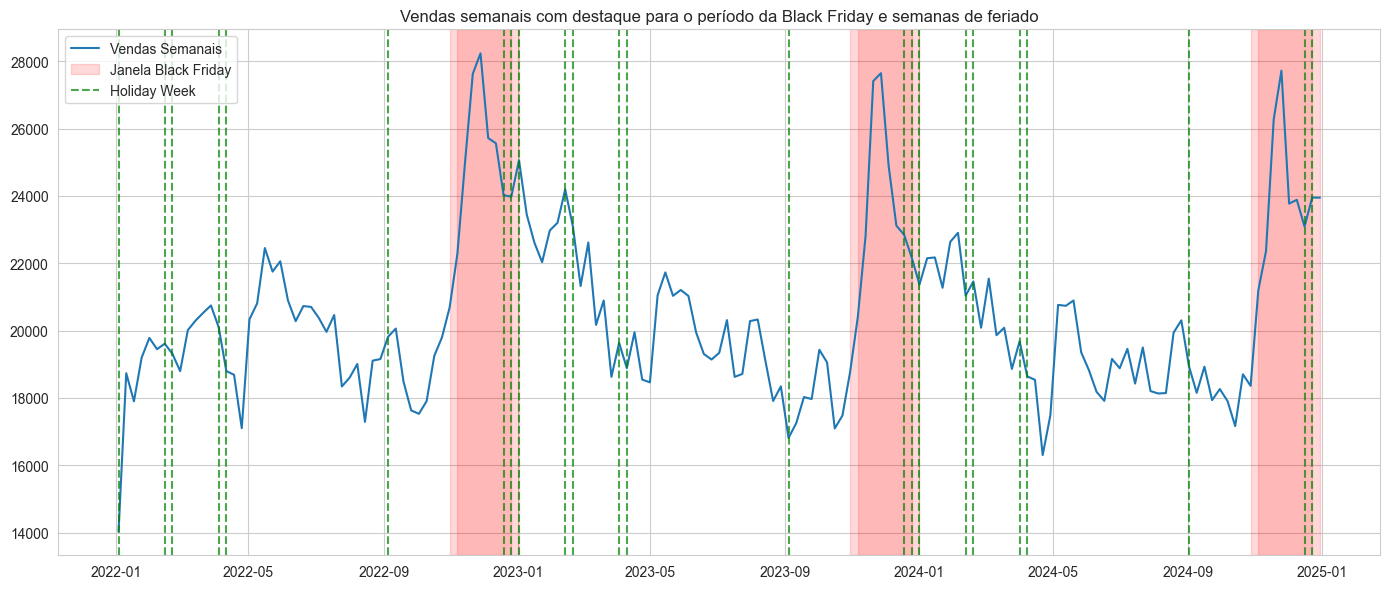

In [ ]:
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(df.index, df[TARGET_COLUMN], label="Vendas Semanais")

label_bf = False
for bf in bf_dates:
    ax.axvspan(
        bf - Week(3),
        bf + Week(5),
        color="red",
        alpha=0.15,
        label="Janela Black Friday" if not label_bf else None
    )
    label_bf = True

for i, d in enumerate(datas_holiday_week):
    ax.axvline(
        d,
        color="green",
        linestyle="--",
        alpha=0.7,
        label="Holiday Week" if i == 0 else None
    )

ax.set_title("Vendas semanais com destaque para o período da Black Friday e semanas de feriado")
ax.legend(loc='upper left')

plt.tight_layout()
plt.show()


#### 5.2.1 - Black Friday

In [ ]:
# Cálculo do lift da Black Friday comparando o valor do target na semana do evento com a média das semanas vizinhas (antes e depois)
lift_bf_nb = df.loc[df['bf_window'] == 1, TARGET_COLUMN].mean()/df.loc[df['bf_neighbor'] == 1, TARGET_COLUMN].mean()

lift_bf = df.loc[df['bf_window'] == 1, TARGET_COLUMN].mean()/df.loc[df['bf_window'] == 0, TARGET_COLUMN].mean()

print(f"Lift da Black Friday: {lift_bf_nb:.2f}x (ou {lift_bf_nb - 1:.2%} de aumento em relação às semanas vizinhas)")
print(f"Lift da Black Friday: {lift_bf:.2f}x (ou {lift_bf - 1:.2%} de aumento em relação ao resto do ano)")

Lift da Black Friday: 1.16x (ou 16.10% de aumento em relação às semanas vizinhas)
Lift da Black Friday: 1.21x (ou 21.20% de aumento em relação ao resto do ano)


#### 5.2.2 - Holiday Weeks

In [22]:
lift_holiday = df.loc[df['holiday_week'] == 1, TARGET_COLUMN].mean()/df.loc[df['holiday_week'] == 0, TARGET_COLUMN].mean()

print(f"Lift de semanas com feriados: {lift_holiday:.2f}x (ou {lift_holiday - 1:.2%} de aumento em relação às semanas sem feriados)")

Lift de semanas com feriados: 1.02x (ou 2.42% de aumento em relação às semanas sem feriados)


C:\Users\vinni\AppData\Local\Temp\ipykernel_2356\3397390438.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes.set_xticklabels(["Non-Holiday", "Holiday"])


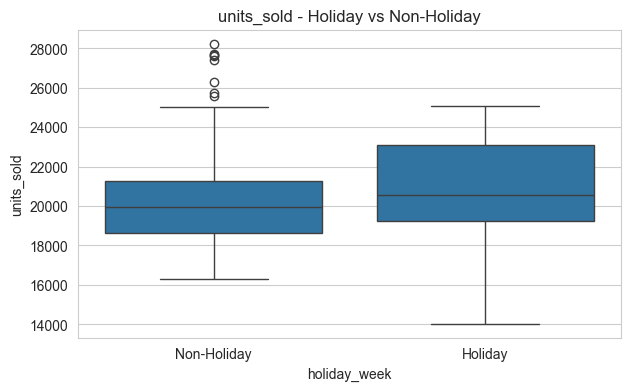

In [23]:
fig, axes = plt.subplots(figsize=(7,4))

sns.boxplot(
    x="holiday_week",
    y=TARGET_COLUMN,
    data=df,
    ax=axes
)
axes.set_title(f"{TARGET_COLUMN} - Holiday vs Non-Holiday")
axes.set_xticklabels(["Non-Holiday", "Holiday"])

plt.show()

In [24]:
df["zscore"] = (df[TARGET_COLUMN] - df[TARGET_COLUMN].mean()) / df[TARGET_COLUMN].std()

outliers = df[np.abs(df["zscore"]) > 3][
    [TARGET_COLUMN, "is_black_friday", "holiday_week", "zscore"]
]

outliers

,units_sold,is_black_friday,holiday_week,zscore
date,,,,
2022-11-28,28233,1,0,3.134876


A análise da série temporal de vendas indica a presença de semanas atípicas concentradas em períodos específicos, notadamente durante a Black Friday. A comparação entre o volume de vendas nas semanas classificadas como Black Friday e a média das semanas vizinhas mostra um lift médio de aproximadamente 16%, chegando a mais de 21% quando comparado ao restante do ano. Além disso, essas semanas apresentam z-scores superiores a 3, caracterizando desvios estatisticamente relevantes.

Esse comportamento consistente e recorrente confirma a Black Friday como um evento exógeno estrutural, que não deve ser tratado como ruído ou removido, mas sim explicitamente modelado por meio de uma variável dummy. A sua inclusão é fundamental para evitar que o modelo atribua esse aumento excepcional de vendas aos canais de mídia, o que resultaria em vieses nos coeficientes e na estimativa de ROI.

Em relação às semanas com feriados, observa-se um efeito positivo leve, com vendas em média cerca de 2% superiores às semanas sem feriados, além de maior dispersão na distribuição. Apesar de o impacto ser moderado, ele sugere a presença de variações exógenas na demanda que não estão diretamente relacionadas às ações de marketing. Dessa forma, a variável `holiday_week` é mantida como controle no modelo para capturar essas flutuações e contribuir para uma melhor estimativa do baseline de vendas.

Por fim, não foram identificados outliers extremos sem explicação causal clara. Os principais desvios observados estão associados a eventos conhecidos, reforçando a decisão de não remover observações, mas sim tratá-las adequadamente no modelo.

### 5.3 - Análise da Série Temporal AS-IS

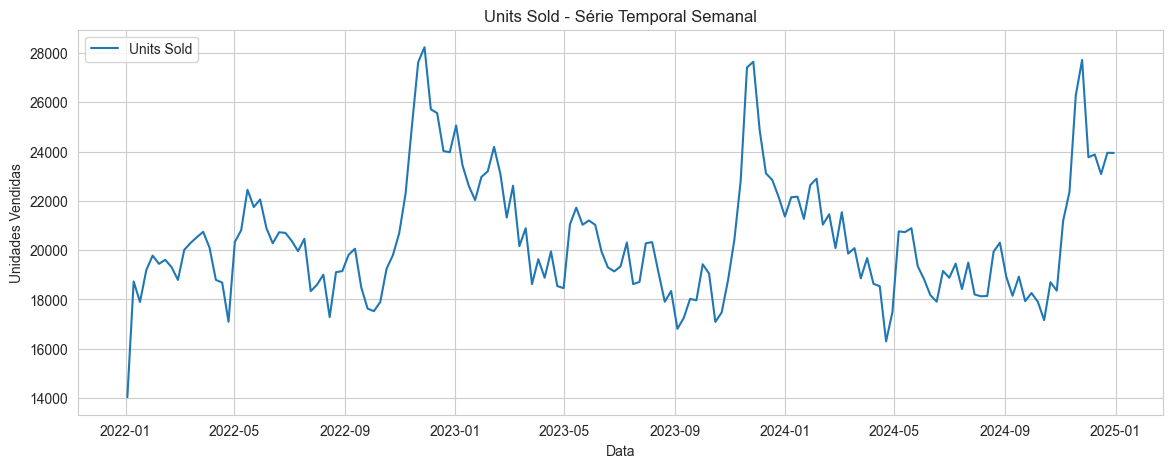

In [25]:
plt.figure(figsize=(14, 5))
plt.plot(y, label="Units Sold")
plt.title("Units Sold - Série Temporal Semanal")
plt.ylabel("Unidades Vendidas")
plt.xlabel("Data")
plt.legend()
plt.show()

#### 5.3.1 - Decomposição de Série Temporal do Target

- Verificação do crescimento orgânico da varejo360 (Tendência)
- Observação do impacto causado pela sazonalidade
- Identificação de resíduos que podem ser picos causados pelas campanhas de Marketing ou Outliers

**Escolha do STL (Seasonal and Trend decomposition using Loess)** <br>
STL é preferível ao seasonal_decompose porque é mais robusto a outliers típicos de picos de mídia, estima melhor tendências <br>
não lineares e permite modelar sazonalidade anual em séries semanais de forma mais estável, evitando viés nos coeficientes do modelo.

Hiperparâmetros utilizados:
- period = 52 → sazonalidade anual (365 dias ~ 52 semanas)
- robust = True → Captura picos de mídia, promoções atípicas e eventos únicos como resíduos (não influenciam tendência e sazonalidade)

In [26]:
stl = STL(
    y,
    period=52,
    robust=True
)

result = stl.fit()

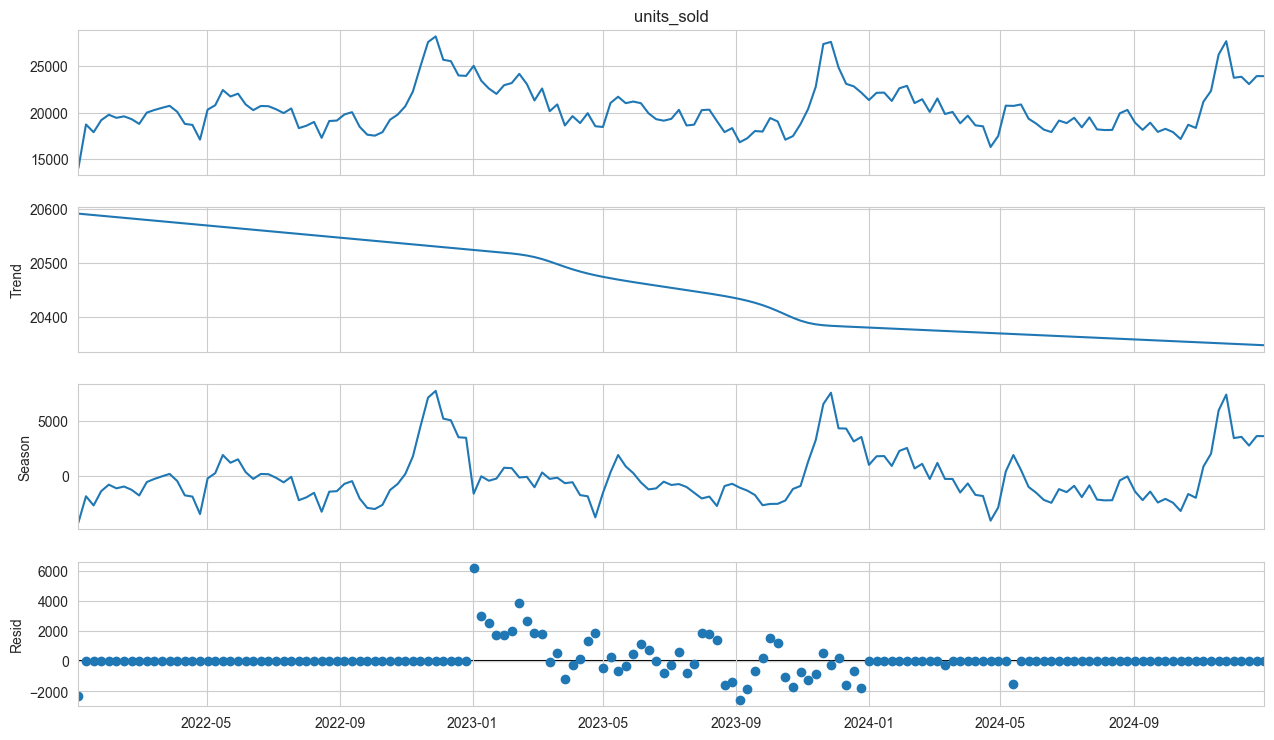

In [27]:
fig = result.plot()
fig.set_size_inches(14, 8)
plt.show()

In [28]:
# Criando dataframe com os componentes da decomposição para análises posteriores
df_decomp = pd.DataFrame({
    "units_sold": y,
    "trend": result.trend,
    "seasonality": result.seasonal,
    "residual": result.resid
})

#### 5.3.2 - Análise da **Tendência**

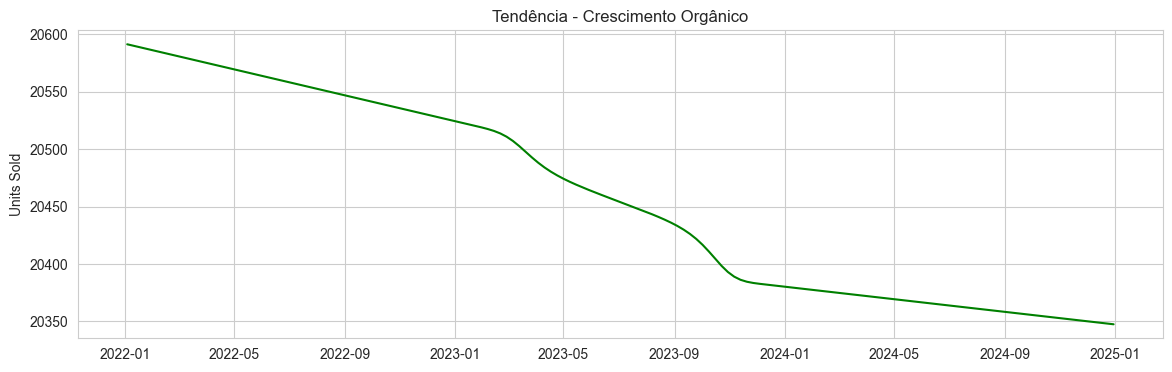

In [29]:
plt.figure(figsize=(14, 4))
plt.plot(df_decomp["trend"], color="green")
plt.title("Tendência - Crescimento Orgânico")
plt.ylabel("Units Sold")
plt.show()

Verifica-se uma queda ao longo do período analisado, contudo, isso representa uma queda de apenas 1.23% durante os 3 anos observados.

#### 5.3.3 - Análise de **Sazonalidade**

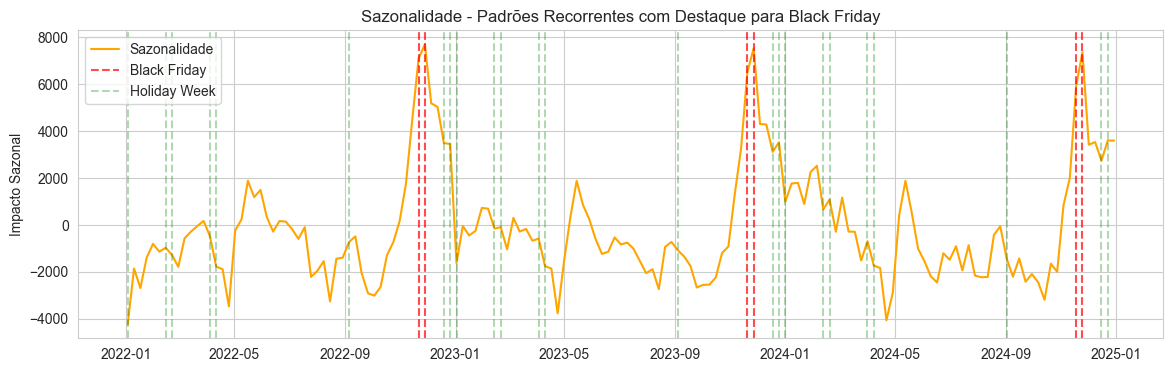

In [30]:
fig, ax = plt.subplots(figsize=(14, 4))

ax.plot(df_decomp.index, df_decomp["seasonality"], label="Sazonalidade", color="orange")

for i, d in enumerate(datas_black_friday):
    ax.axvline(
        d,
        color="red",
        linestyle="--",
        alpha=0.7,
        label="Black Friday" if i == 0 else None
    )
    
for i, d in enumerate(datas_holiday_week):
    ax.axvline(
        d,
        color="green",
        linestyle="--",
        alpha=0.3,
        label="Holiday Week" if i == 0 else None
    )

ax.set_title("Sazonalidade - Padrões Recorrentes com Destaque para Black Friday")
ax.set_ylabel("Impacto Sazonal")
ax.legend(loc='upper left')

plt.show()


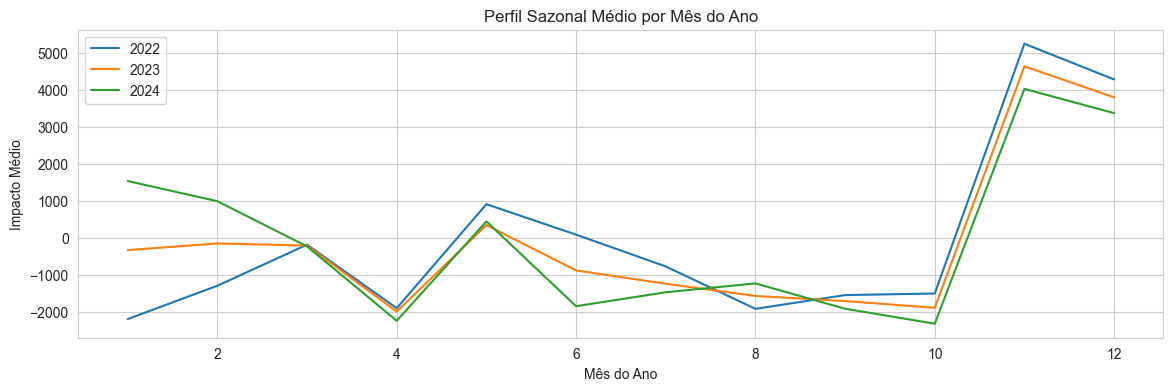

In [31]:
season_month = df_decomp.groupby(
    [df_decomp.index.month, df_decomp.index.year]
).agg({'seasonality': 'mean'})['seasonality'].unstack(level=1)

plt.figure(figsize=(14, 4))
plt.plot(season_month, label=season_month.columns.values)
plt.title("Perfil Sazonal Médio por Mês do Ano")
plt.xlabel("Mês do Ano")
plt.ylabel("Impacto Médio")
plt.legend()
plt.show()

#### 5.3.4 - Análise dos **Resíduos**

In [35]:
threshold = df_decomp["residual"].std() * 3

outliers = df_decomp[
    np.abs(df_decomp["residual"]) > threshold
]

outliers[["units_sold", "residual"]]

,units_sold,residual
date,,
2023-01-02,25059,6158.790544
2023-01-09,23449,2970.917305
2023-02-13,24191,3831.163665


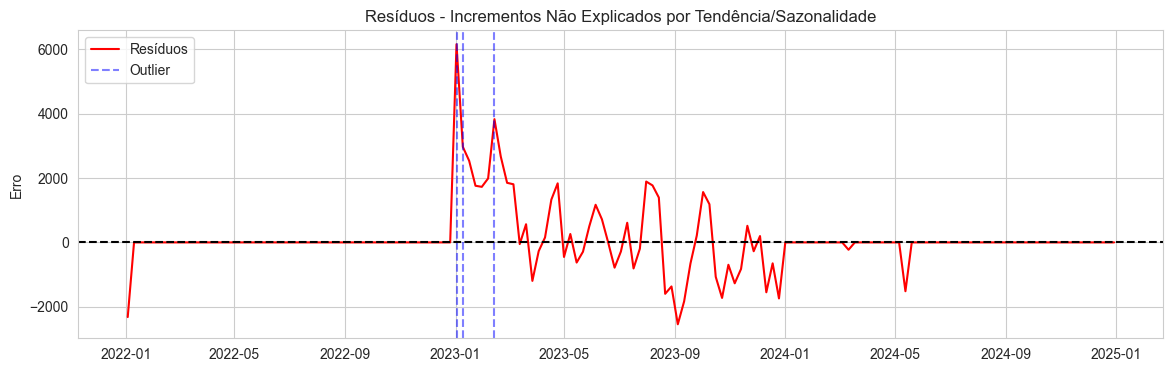

In [36]:
fig, ax = plt.subplots(figsize=(14, 4))

ax.plot(df_decomp["residual"], label="Resíduos", color="red")

for i, d in enumerate(outliers.index.values):
    ax.axvline(
        d,
        color="blue",
        linestyle="--",
        alpha=0.5,
        label="Outlier" if i == 0 else None
    )
    
ax.axhline(0, linestyle="--", color="black")
ax.set_title("Resíduos - Incrementos Não Explicados por Tendência/Sazonalidade")
ax.set_ylabel("Erro")
ax.legend(loc='upper left')
plt.show()


In [37]:
adf_result = adfuller(df_decomp["residual"].dropna())

print(f"ADF Statistic: {adf_result[0]:.3f}")
print(f"p-value: {adf_result[1]:.5f}")

ADF Statistic: -2.813
p-value: 0.05638


O teste ADF aplicado aos resíduos da decomposição STL resultou em um p-value marginalmente acima de 5%, sugerindo uma leve evidência de não estacionariedade. <br>
Dado o tamanho reduzido da amostra e a presença de eventos promocionais recorrentes, esse resultado é interpretado como aceitável no contexto de MMM. <br>
Entretanto, a seguir, será realizado o pré-tratamento do evento da Black Friday para tornar os resíduos da distribuição mais estacionários. 

### 5.4 - Análise da Série Temporal com pré-tratamento de Black Friday

Embora a Black Friday apresente caráter recorrente, sua intensidade e sincronização com investimentos de mídia variam ao longo do tempo. Por isso, optou-se por tratá-la como um evento exógeno via variável dummy, evitando que seu impacto fosse absorvido indevidamente pela sazonalidade.

In [38]:
df_clean = df.copy()

In [39]:
bf_dates = pd.to_datetime(datas_black_friday)

In [40]:
# Nestes pesos foi levado em conta que, no dataset disponibilizado, existem marcações sempre em duas semanas consecutivas antes da Black Friday.
weights = {
    -3: 0.2,
    -2: 0.3,
    -1: 0.5,
     0: 0.7,
     1: 0.5,
     2: 0.4,
     3: 0.3,
     4: 0.2,
     5: 0.15
}

df_clean["bf_weighted"] = 0.0

for bf in bf_dates:
    for lag, w in weights.items():
        date = bf + Week(lag)
        if pd.to_datetime(date) in df_clean.index:
            df_clean.loc[date, "bf_weighted"] += w

In [41]:
# Calculando o parâmetro bf_effect como o impacto médio por unidade de peso da janela de Black Friday
bf_effect = (
    (df_clean["bf_weighted"] * df_clean["units_sold"]).sum()
    / df_clean["bf_weighted"].sum()
    - df_clean.loc[df_clean["bf_weighted"] == 0, "units_sold"].mean()
)

print(f"Impacto Médio Estimado da Black Friday (bf_effect): {bf_effect:.2f} unidades vendidas por unidade de peso")

df_clean["units_sold_adj"] = df_clean["units_sold"] - df_clean["bf_weighted"] * bf_effect

Impacto Médio Estimado da Black Friday (bf_effect): 5247.33 unidades vendidas por unidade de peso


In [42]:
stl_adj = STL(
    df_clean["units_sold_adj"],
    period=52,
    robust=True
)

result_adj = stl_adj.fit()

In [43]:
# Criando dataframe com os componentes da decomposição para análises posteriores
df_decomp_adj = pd.DataFrame({
    "units_sold": y,
    "trend": result_adj.trend,
    "seasonality": result_adj.seasonal,
    "residual": result_adj.resid
})

#### 5.4.1 - Análise de **Sazonalidade** - Comparação entre a decomposição com e sem tratamento da Black Friday

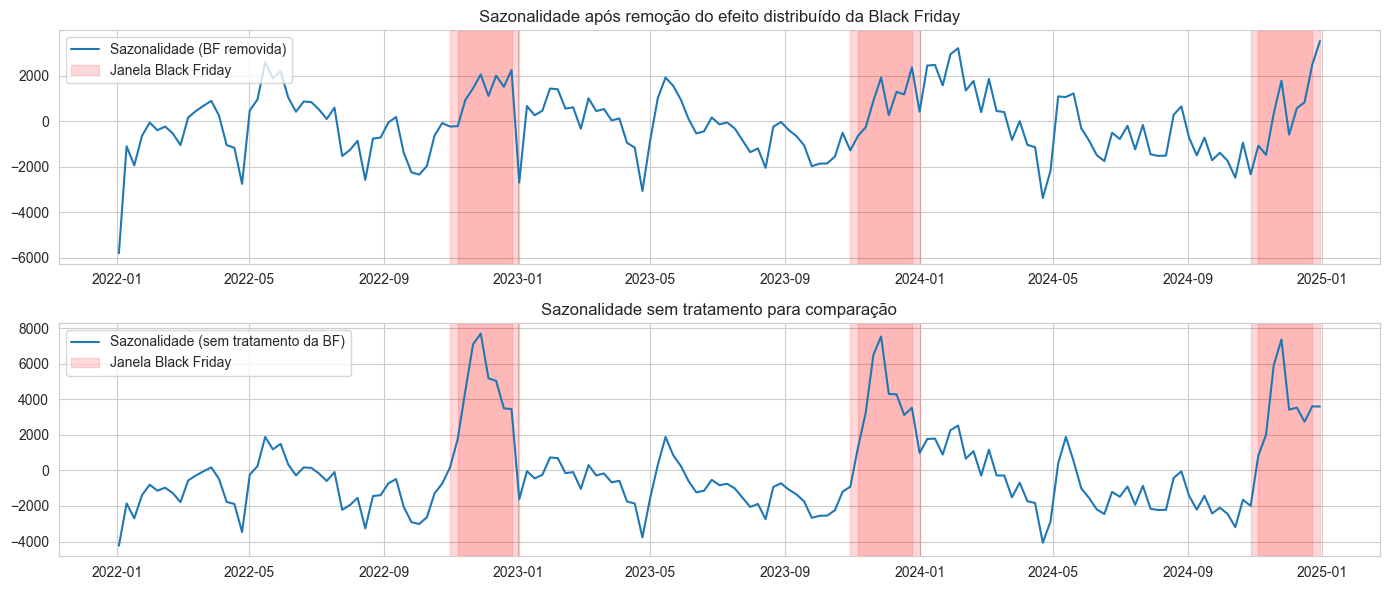

In [44]:
fig, ax = plt.subplots(2, 1, figsize=(14, 6))

ax[0].plot(df_clean.index, result_adj.seasonal, label="Sazonalidade (BF removida)")

label_bf = False
for bf in bf_dates:
    ax[0].axvspan(
        bf - Week(3),
        bf + Week(5),
        color="red",
        alpha=0.15,
        label="Janela Black Friday" if not label_bf else None
    )
    label_bf = True

ax[0].set_title("Sazonalidade após remoção do efeito distribuído da Black Friday")
ax[0].legend(loc='upper left')


ax[1].plot(df.index, result.seasonal, label="Sazonalidade (sem tratamento da BF)")
label_bf = False
for bf in bf_dates:
    ax[1].axvspan(
        bf - Week(3),
        bf + Week(5),
        color="red",
        alpha=0.15,
        label="Janela Black Friday" if not label_bf else None
    )
    label_bf = True

ax[1].set_title("Sazonalidade sem tratamento para comparação")
ax[1].legend()

plt.tight_layout()
plt.show()


Como o STL não aceita variáveis exógenas, o tratamento da Black Friday foi feito via pré-ajuste da série: estimou-se separadamente o efeito distribuído do evento e o choque identificado foi removido antes da decomposição. Assim, a sazonalidade estimada representa apenas padrões estruturais, enquanto o impacto promocional é tratado explicitamente como controle no MMM.

Apesar de modelarmos a Black Friday com uma dinâmica semelhante a um adstock, ela permanece uma variável de controle, pois não representa uma decisão de alocação de mídia. O adstock aqui é usado apenas para capturar a persistência temporal de um choque exógeno, evitando que seu efeito seja indevidamente atribuído aos canais.

#### 5.4.2 Análise de **Tendência**

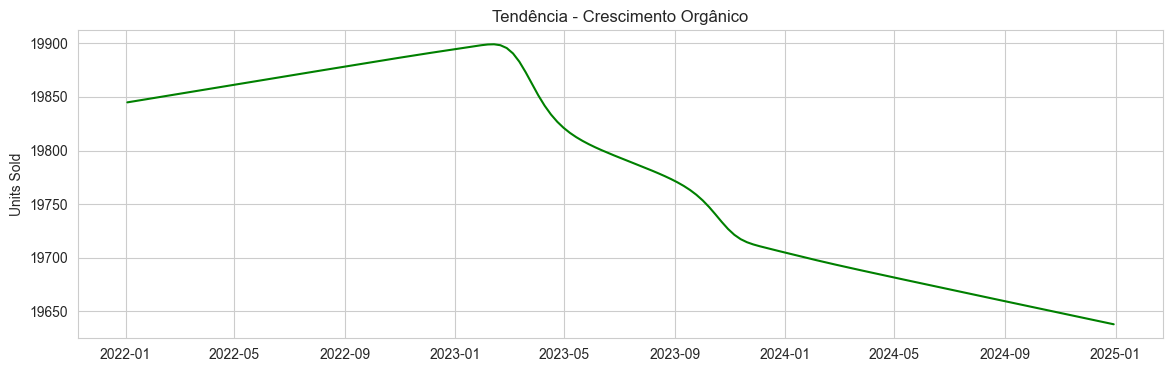

In [45]:
plt.figure(figsize=(14, 4))
plt.plot(df_decomp_adj["trend"], color="green")
plt.title("Tendência - Crescimento Orgânico")
plt.ylabel("Units Sold")
plt.show()

#### 5.4.3 - Análise de **Resíduos**

In [46]:
threshold = df_decomp_adj["residual"].std() * 3

outliers = df_decomp_adj[
    np.abs(df_decomp_adj["residual"]) > threshold
]

outliers[["units_sold", "residual"]]

,units_sold,residual
date,,
2023-01-02,25059,7079.112784
2023-02-13,24191,3745.775304


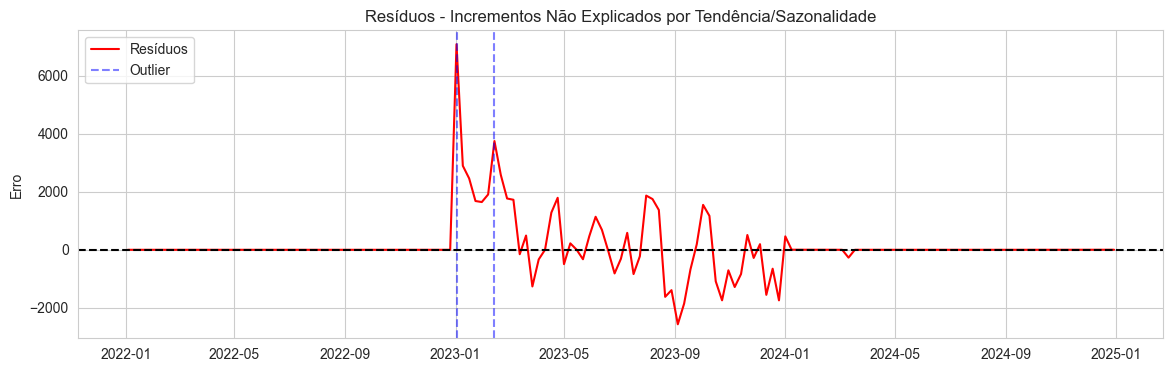

In [47]:
fig, ax = plt.subplots(figsize=(14, 4))

ax.plot(df_decomp_adj["residual"], label="Resíduos", color="red")

for i, d in enumerate(outliers.index.values):
    ax.axvline(
        d,
        color="blue",
        linestyle="--",
        alpha=0.5,
        label="Outlier" if i == 0 else None
    )
    
ax.axhline(0, linestyle="--", color="black")
ax.set_title("Resíduos - Incrementos Não Explicados por Tendência/Sazonalidade")
ax.set_ylabel("Erro")
ax.legend(loc='upper left')
plt.show()


In [48]:
adf_result = adfuller(df_decomp_adj["residual"].dropna())

print(f"ADF Statistic: {adf_result[0]:.3f}")
print(f"p-value: {adf_result[1]:.5f}")

ADF Statistic: -6.697
p-value: 0.00000


Inicialmente, os resíduos da decomposição apresentavam evidência marginal de não estacionariedade, sugerindo que eventos promocionais relevantes ainda estavam contaminando o baseline. <br>
Após modelar explicitamente a Black Friday como um choque exógeno com efeito distribuído no tempo e remover esse impacto antes da decomposição, <br> os resíduos tornaram-se claramente estacionários (ADF p-value < 0.001), indicando que a estrutura temporal foi adequadamente isolada.

### 5.5 - Análise de Investimento em mídia



#### 5.5.1 - Análise de Padrões de Investimento

Nesta etapa será verificado o comportamento da empresa quanto aos canais de mídia. Se são realizadas campanhas Always-On ou Flighting.

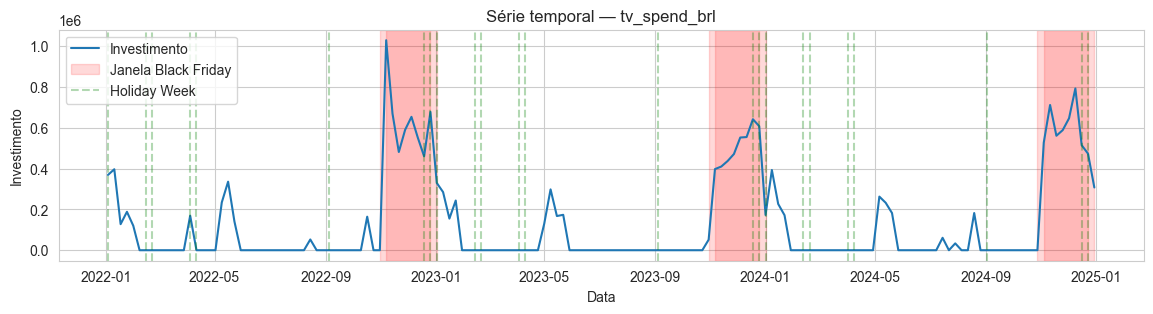

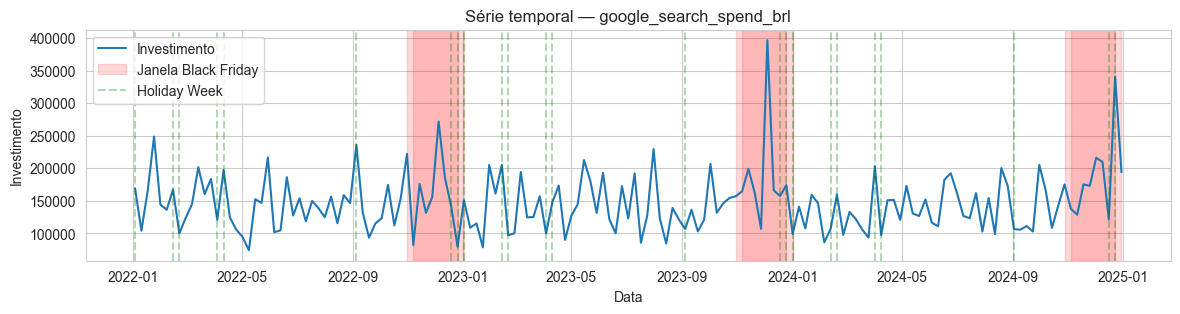

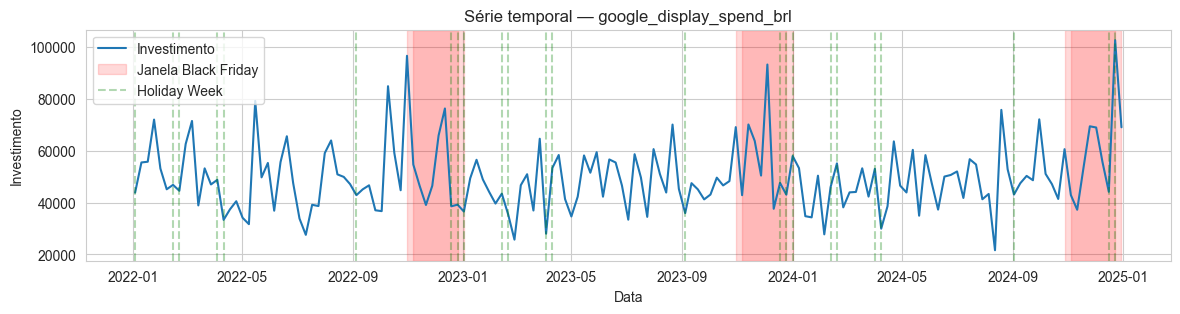

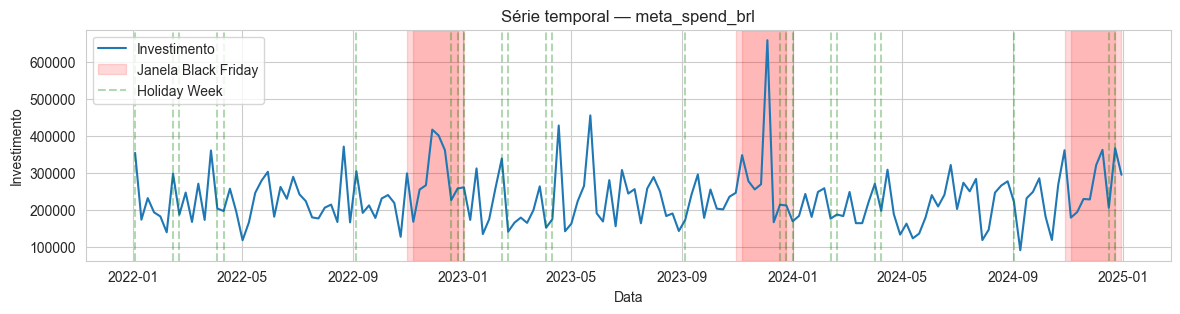

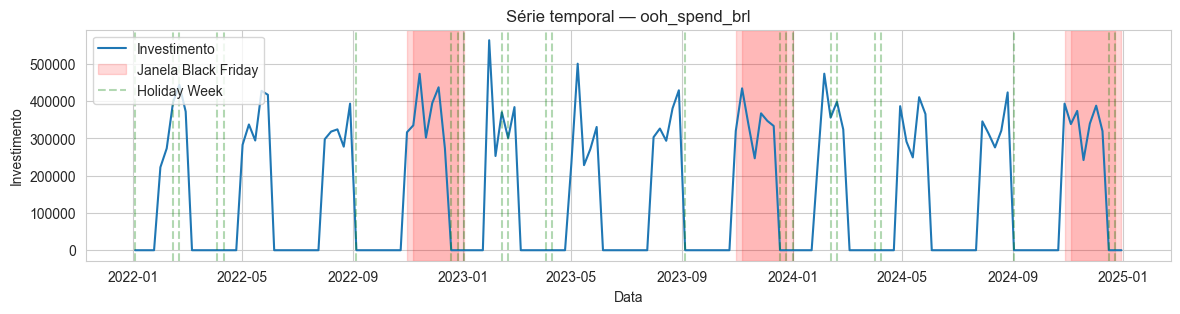

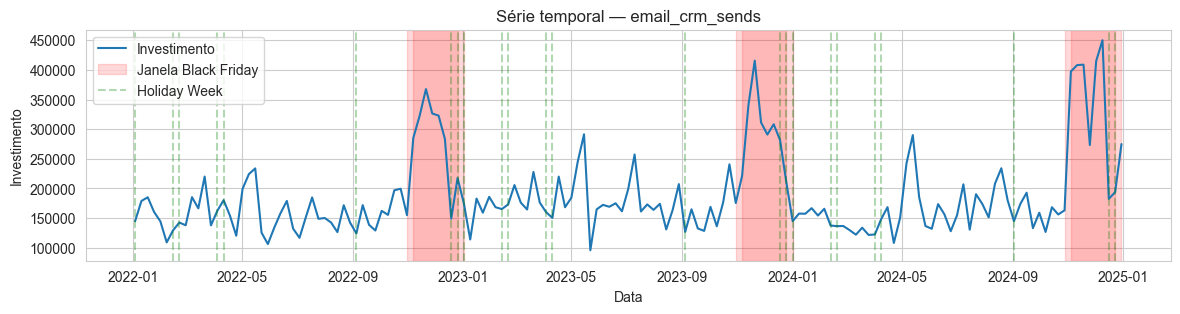

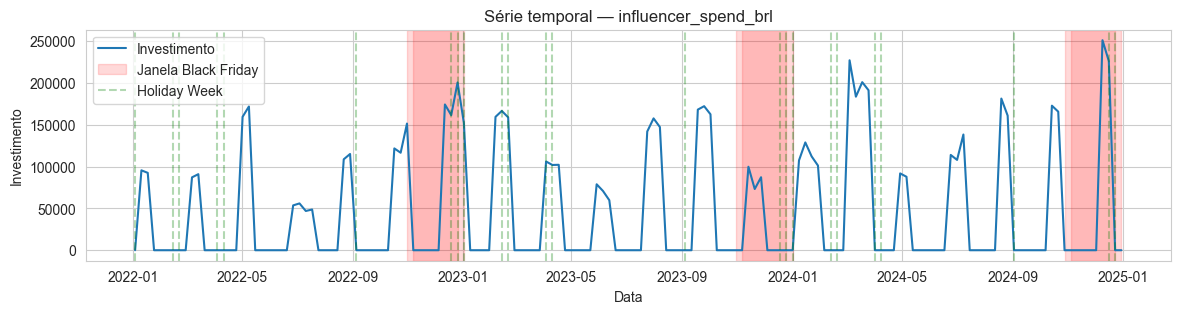

In [ ]:
for channel in media_channels:
    fig, ax = plt.subplots(figsize=(14, 3))

    ax.plot(df.index, df[channel], label='Investimento')

    label_bf = False
    for bf in bf_dates:
        ax.axvspan(
            bf - Week(3),
            bf + Week(5),
            color="red",
            alpha=0.15,
            label="Janela Black Friday" if not label_bf else None
        )
        label_bf = True

    for i, d in enumerate(datas_holiday_week):
        ax.axvline(
            d,
            color="green",
            linestyle="--",
            alpha=0.3,
            label="Holiday Week" if i == 0 else None
        )
    ax.set_title(f"Série temporal — {channel}")
    ax.set_xlabel("Data")
    ax.set_ylabel("Investimento")
    ax.legend(loc='upper left')
    plt.show()


O padrão de flighting observado nos dados sugere ativações coordenadas entre canais, trazendo simultaneidade de investimento e elevada multicolinearidade. Isso reduz a capacidade do MMM de identificar efeitos incrementais isolados, exigindo cautela na interpretação dos coeficientes e reforçando a importância de controles sazonais e escolhas cuidadodas de variáveis.

#### 5.5.2 - Métricas Quantitativas de Investimento

In [50]:
flighting_summary = []

for channel in media_channels:
    series = df[channel]
    
    summary = {
        "canal": channel,
        "% semanas ativas": pct_active(series),
        "media gasto (quando ativo)": series[series > 0].mean(),
        "coef_variacao (quando ativo)": coeff_variation(series),
        "num_bursts": count_bursts(series)
    }
    
    flighting_summary.append(summary)

flighting_df = pd.DataFrame(flighting_summary)
flighting_df.sort_values("% semanas ativas", ascending=False)

,canal,% semanas ativas,media gasto (quando ativo),coef_variacao (quando ativo),num_bursts
1,google_search_spend_brl,1.000000,146985.375478,0.314813,1
2,google_display_spend_brl,1.000000,49590.792675,0.266372,1
3,meta_spend_brl,1.000000,231282.099172,0.326819,1
5,email_crm_sends,1.000000,186898.617834,0.369836,1
4,ooh_spend_brl,0.420382,344216.348939,0.204915,12
6,influencer_spend_brl,0.356688,131670.169286,0.366817,20
0,tv_spend_brl,0.350318,369985.075636,0.600260,13


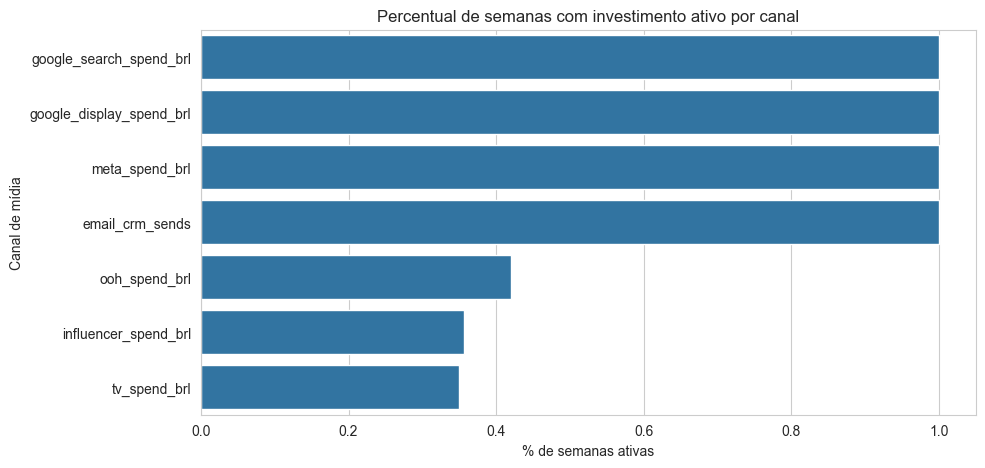

In [51]:
plt.figure(figsize=(10, 5))
sns.barplot(
    data=flighting_df.sort_values("% semanas ativas", ascending=False),
    x="% semanas ativas",
    y="canal"
)
plt.title("Percentual de semanas com investimento ativo por canal")
plt.xlabel("% de semanas ativas")
plt.ylabel("Canal de mídia")
plt.show()

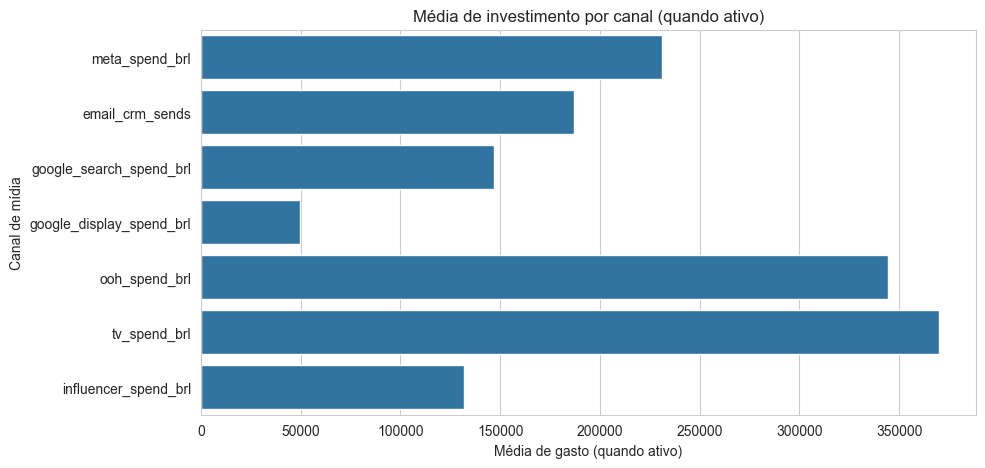

In [52]:
plt.figure(figsize=(10, 5))
sns.barplot(
    data=flighting_df.sort_values(["num_bursts", "media gasto (quando ativo)"], ascending=[True, False]),
    x="media gasto (quando ativo)",
    y="canal"
)
plt.title("Média de investimento por canal (quando ativo)")
plt.xlabel("Média de gasto (quando ativo)")
plt.ylabel("Canal de mídia")
plt.show()

##### Flighting - Liga/Desliga vs Always-on

Observando-se os investimentos, é possível verificar os seguintes formatos:<br>
**Flighting**
- `tv_spend_brl`
- `ooh_spend_brl`
- `influencer_spend_brl` <br>

**Always-On**
- `google_search_spend_brl`
- `google_display_spend_brl`
- `meta_spend_brl` <br>

**Híbrido (Always-On + Flighting)**
- `email_crm_sends`


TV, OOH e Influencers apresentam padrão claro de flighting, com longos períodos sem investimento seguidos de bursts concentrados. <br> 
Já Google e Meta operam de forma predominantemente contínua, sugerindo comportamento always-on. <br>
Por fim, emails possuem comportamento híbrido sendo sempre presentens, mas com intensidade maior durante o período da Black Friday. <br> 

Essas diferenças têm implicações diretas na modelagem:
- Canais em flighting exigem maior atenção à calibração de adstock, dado o efeito de memória.
- Canais always-on tendem a apresentar maior correlação entre si, aumentando o risco de multicolinearidade.


### 5.6 - Estudo de Multicolinearidade

Correlação alta entre canais compromete a identificação causal, pois o modelo não consegue separar efeitos marginais individuais de cada mídia.

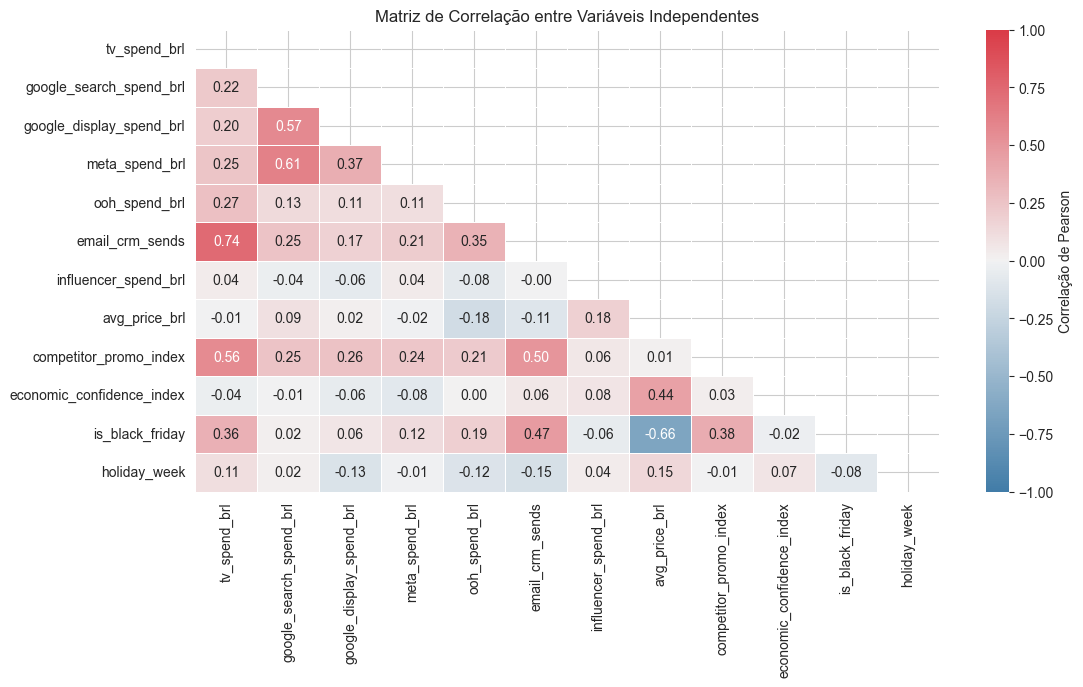

In [54]:
media_and_controls = media_channels + control_features
plt.figure(figsize=(12, 6))

corr = df[media_and_controls].corr(method="pearson")

cmap = sns.diverging_palette(240, 10, as_cmap=True)  # azul->vermelho
# Máscara para mostrar apenas triângulo inferior
mask = np.triu(np.ones_like(corr, dtype=bool))


ax = sns.heatmap(
        corr,
        mask=mask,
        cmap=cmap,
        vmin=-1,
        vmax=1,  # intensidade fixa em [-1, 1]
        center=0,
        annot=True,
        fmt=".2f",  # anotações opcionais
        linewidths=0.5,
        cbar_kws={"label": "Correlação de Pearson"},
    )

ax.set_title('Matriz de Correlação entre Variáveis Independentes')
plt.show()


#### 5.6.1 - Insights retirados da análise de correlação
A matriz de correlação entre as variáveis independentes indica que não há multicolinearidade extrema generalizada, mas existem blocos específicos de variáveis com correlação moderada a alta, que impõem limitações claras à identificação causal dos efeitos individuais no modelo de MMM.

##### Correlação elevada entre TV e Email CRM
> tv_spend_brl ↔ email_crm_sends: 0.74
- Indica que a orquestração de campanhas que envolvem bursts de mídia de TV são acompanhados de ativações de CRM.
- **Decisão**: Manter ambos, com ressalvas de limitação de identificação.

##### Correlação moderada entre canais digitais de performance
> Google Search ↔ Meta Ads: 0.61 <br>
> Google Search ↔ Google Display: 0.57 <br>
> Meta Ads ↔ Google Display: 0.37 <br>
- Indica planejamentos digitais conjuntos, com alocação simultânea entre canais do mesmo stack de performance.
- Esses canais competem pela mesma demanda latente.
- Modelo conseguirá capturar bem o efeito combinado dos canais, porém não será necessariamente preciso na distinção entre os canais.
- **Decisão**: Manter canais separados e considerar as limitações.

##### Relação entre TV e pressão competitiva
> tv_spend_brl ↔ competitor_promo_index: 0.56 <br>
- Indica aumento de investimento em TV em períodos de maior agressividade promocional da concorrência.
- Não implica causalidade, mas correlação por reação estratégica.
- **Decisão**: Utilizar a pressão competitiva como variável controle.

##### Black Friday e variáveis operacionais
> is_black_friday ↔ avg_price_brl: -0.66 <br>
> is_black_friday ↔ economic_confidence_index: 0.38 <br>
> is_black_friday ↔ email_crm_sends: 0.47 <br>
- Queda estrutural do preço na Black Friday valida as correlações com preço e sentimento dos consumidores.
- Durante a Black Friday é possível observar forte atuação do CRM.
- **Decisão**: Utilizar a flag `is_black_friday` como variável controle.

##### Variáveis com baixa colinearidade
- `influencer_spend_brl` apresenta correlação próxima de zero com quase todos os canais.
- `holiday_week` tem correlações baixas e difusas.


A análise de multicolinearidade indica que, embora não haja colinearidade extrema generalizada, existem blocos de variáveis — especialmente TV, CRM e canais digitais — que variam de forma coordenada ao longo do tempo. <br>
Isso impõe limites claros à identificação causal individual dos coeficientes de mídia. Como consequência, decisões de inclusão de variáveis de controle, aceitação de trade-offs entre ajuste e inferência, e foco na interpretação conjunta de canais são fundamentais para garantir estabilidade e coerência do modelo.




### 5.7 - Identificação de Desafios Causais


#### 5.7.1 - Vendas vs. Comissões e Cupons
Verificação de Endogeneidade

Hipótese causal:

Unidades Vendidas → Cupons Resgatados<br>
Unidades Vendidas → Comissão de Afiliados

Logo, `affiliate_commission_brl` e `coupons_redeemed` não são causas independentes de vendas, são funções determinísticas ou quase determinísticas das vendas.

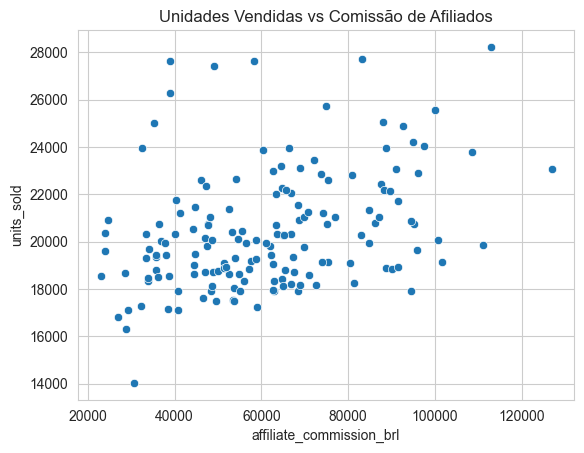

In [82]:
sns.scatterplot(
    data=df,
    x="affiliate_commission_brl",
    y="units_sold"
)
plt.title("Unidades Vendidas vs Comissão de Afiliados")
plt.show()



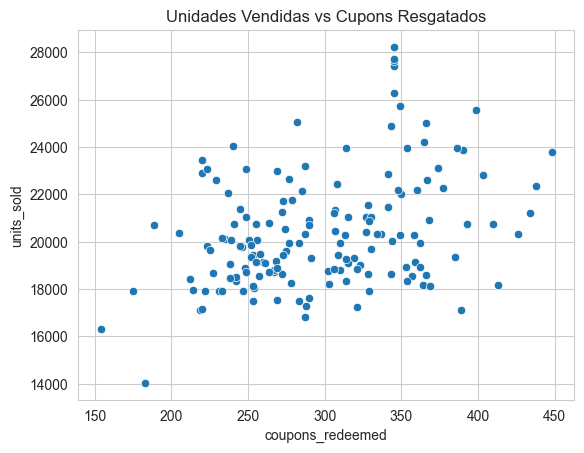

In [81]:
sns.scatterplot(
    data=df,
    x="coupons_redeemed",
    y="units_sold"
)
plt.title("Unidades Vendidas vs Cupons Resgatados")
plt.show()

Tratando Outliers de `coupons_redeemed`

In [69]:
df.loc[df['coupons_redeemed'] > df['coupons_redeemed'].mean() + 3 * df['coupons_redeemed'].std(), 'coupons_redeemed'] = np.round(df['coupons_redeemed'].mean())

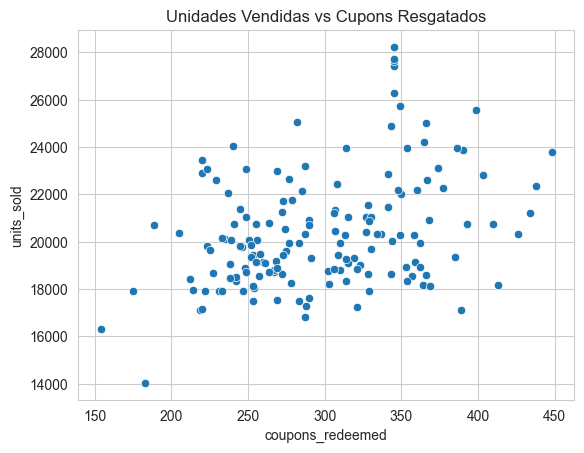

In [70]:
sns.scatterplot(
    data=df,
    x="coupons_redeemed",
    y="units_sold"
)
plt.title("Unidades Vendidas vs Cupons Resgatados")
plt.show()

Apesar de a relação visual entre `units_sold` e `affiliate_commission_brl`/`coupons_redeemed` não ser perfeitamente linear, a questão central não é correlação, mas endogeneidade estrutural. <br>
Ambas as variáveis são consequências diretas do evento de venda, ocorrendo no mesmo momento ou após a transação, e portanto não podem ser tratadas como causas independentes de demanda. <br>
A dispersão observada decorre de variações no ticket médio, mix de produtos e uso de descontos, mas não altera a direção causal fundamental. <br>
A inclusão dessas variáveis introduziria viés por simultaneidade e comprometeria a interpretação causal dos coeficientes do modelo de MMM.

**Conclusão**: Excluir `affiliate_commission_brl` e `coupons_redeemed` da modelagem.

##### Analisando pela ótica de `revenue_brl`

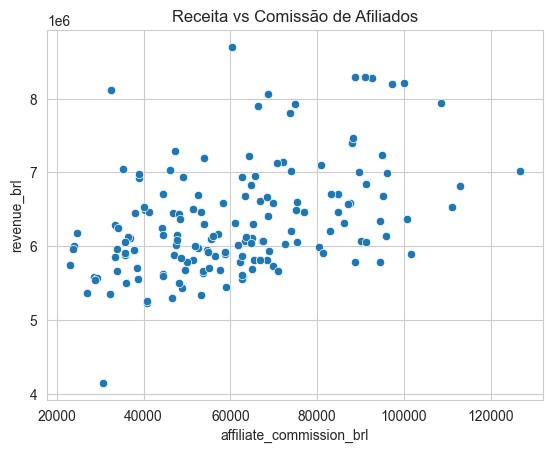

In [85]:
sns.scatterplot(
    data=df,
    x="affiliate_commission_brl",
    y="revenue_brl"
)
plt.title("Receita vs Comissão de Afiliados")
plt.show()



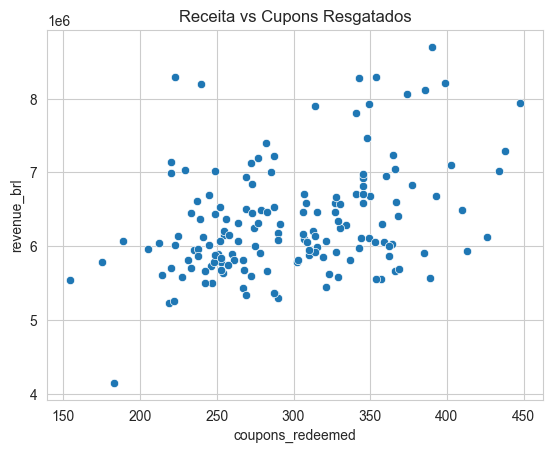

In [86]:
sns.scatterplot(
    data=df,
    x="coupons_redeemed",
    y="revenue_brl"
)
plt.title("Receita vs Cupons Resgatados")
plt.show()

Ao utilizar `revenue_brl` como variável target, observa-se uma relação quase linear entre receita e `affiliate_commission_brl`, bem como uma forte associação positiva com `coupons_redeemed`.
Essa relação não representa causalidade no sentido requerido pelo MMM, mas sim endogeneidade estrutural: ambas as variáveis são consequências diretas da própria venda, calculadas no momento da transação com base no valor faturado. <br>
A inclusão dessas variáveis no modelo introduziria viés por simultaneidade, inflando o poder explicativo e competindo indevidamente com os canais de mídia pela variância da receita.
Portanto, `affiliate_commission_brl` e `coupons_redeemed` são excluídas do modelo por não serem causas independentes de demanda, apesar de sua alta associação com o target.

#### 5.7.2 - Mídia vs. Sessões no Site
Verificação de Competição pela Causa <br>

Hipótese Causal: <br>
Mídia → Sessões → Vendas

In [71]:
df["total_media_spend"] = df[media_channels].sum(axis=1)

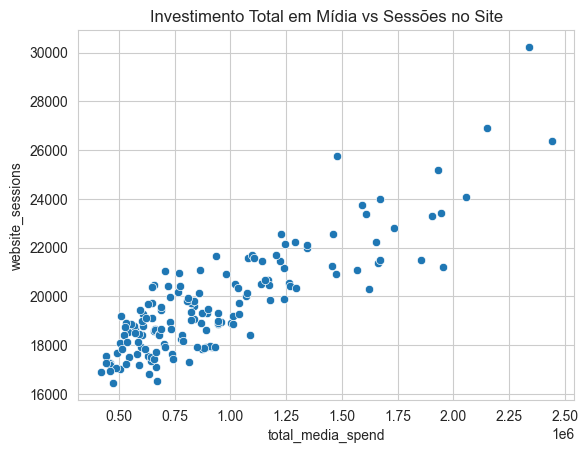

In [72]:
sns.scatterplot(
    data=df,
    x="total_media_spend",
    y="website_sessions"
)
plt.title("Investimento Total em Mídia vs Sessões no Site")
plt.show()

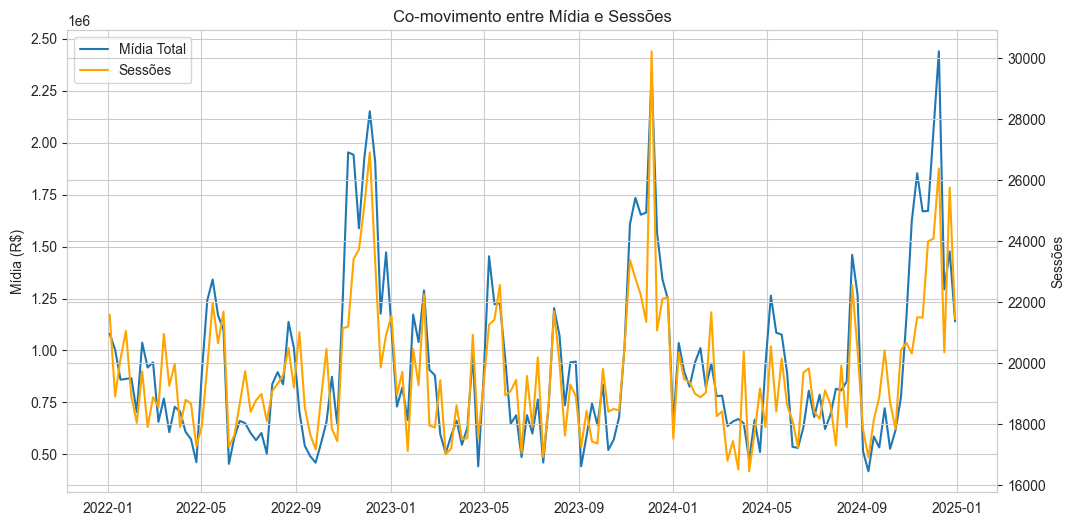

In [80]:
fig, ax1 = plt.subplots(figsize=(12,6))

l1, = ax1.plot(df.index, df["total_media_spend"], label="Mídia Total")
ax1.set_ylabel("Mídia (R$)")

ax2 = ax1.twinx()
l2, =ax2.plot(df.index, df["website_sessions"], color="orange", label="Sessões")
ax2.set_ylabel("Sessões")


# Junta as legendas dos dois eixos
lines = [l1, l2]
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc="upper left")

plt.title("Co-movimento entre Mídia e Sessões")
plt.show()

A análise visual mostra forte correlação e co-movimento entre investimento total em mídia e `website_sessions`. <br>
Isso caracteriza `website_sessions` como uma variável mediadora do efeito da mídia, e não um driver independente de vendas. <br>
Sua inclusão no modelo absorveria parte do efeito que deveria ser atribuído corretamente aos canais de mídia.

**Conclusão:** excluir `website_sessions` da modelagem.